https://ryuzyproject.tistory.com/185

## 1. 오토인코더
오토인코더(Autoencoder)는 입력 데이터를 효율적으로 압축하고 다시 복원하는 것을 목표로 하는 인공신경망 기반의 비지도 학습 모델입니다. 

인코더(encoder)라는 신경망 구조를 통해 입력 데이터를 저차원(latent space)의 잠재 표현으로 변환하고, 디코더(decoder)를 통해 이를 다시 원래의 입력 데이터로 복원합니다. 

학습은 원본 입력과 복원된 출력 간의 재구성 오류(reconstruction error)를 최소화하는 방식으로 이루어지며, 이를 통해 데이터의 핵심 특징을 추출하거나 노이즈 제거, 차원 축소 등에 활용됩니다. 

오토인코더는 생성 모델의 기초가 되는 구조로서, 이후 변분 오토인코더(VAE)나 GAN과 같은 발전된 모델에도 큰 영향을 주었습니다.

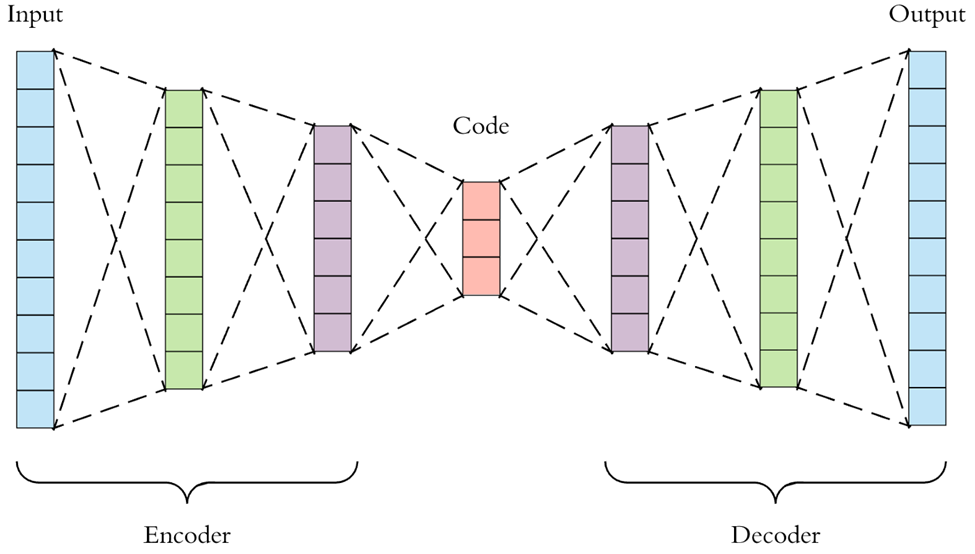

- Autoencoder는 입력을 정답으로 사용하는 신경망
- 예) 숫자 이미지 7을 입력하면 정답도 7 이미지

입력 이미지 x > Encoder > Latent Vector z > Decoder > 복원 이미지 x_hat

> 원본 x와 복원된 결과 x_hat의 차이가 작아지도록 학습

### 비지도 학습

- 일반적인 이미지 분류
    - 강아지 이미지 > CNN > "강아지"

- Autoencoder
    - 강아지 이미지 > Encoder > Latent > Decoder > 강아지 이미지
    - 별도의 클래스 라벨이 필요하지 않기 때문에 전통적으로 비지도 학습 또는 자기지도적 표현 학습의 한 형태로 말함

## 2. Decoder

- Decoder는 Encoder와 반대 방향으로 동작
- 예) latent z (32개 값) > Decoder > 784차원(28 × 28)
- Encoder가 남긴 제한된 정보만 보고 원본과 최대한 비슷한 데이터를 만드는 것

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(2026)

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
  train_dataset, 
  batch_size=128, 
  shuffle=True, 
  num_workers=4,
  persistent_workers=True
)
test_loader = DataLoader(
  test_dataset, 
  batch_size=128, 
  shuffle=False, 
  num_workers=4,
  persistent_workers=True
)

images, labels = next(iter(train_loader))
print("images:", images.shape)   # [B, 1, 28, 28]
print("labels:", labels.shape)

images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])


In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),                                                     # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(
                16, 1, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),                                                     # 14 -> 28
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat


model = ConvAutoencoder().to(DEVICE)
model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [5]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

def train_autoencoder(model, loader, criterion, optimizer, device, epochs=2):
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, _ in loader:
            x = x.to(device)

            _, x_hat = model(x)
            loss = criterion(x_hat, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.6f}")

    return history

history = train_autoencoder(
    model, train_loader, criterion, optimizer, DEVICE, epochs=5
)

Epoch 01/5 | Loss: 0.030150
Epoch 02/5 | Loss: 0.001699
Epoch 03/5 | Loss: 0.001103
Epoch 04/5 | Loss: 0.000877
Epoch 05/5 | Loss: 0.000735


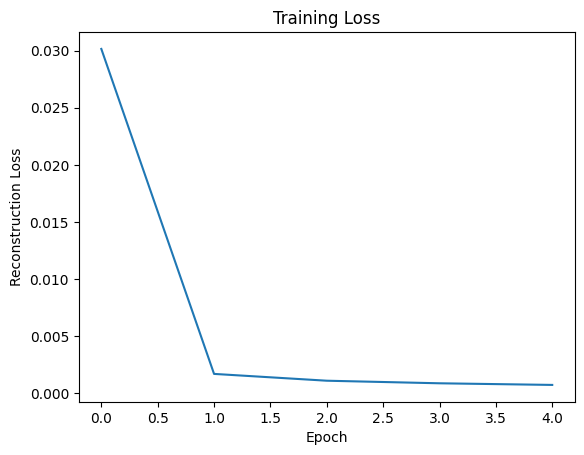

In [6]:
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Training Loss")
plt.show()

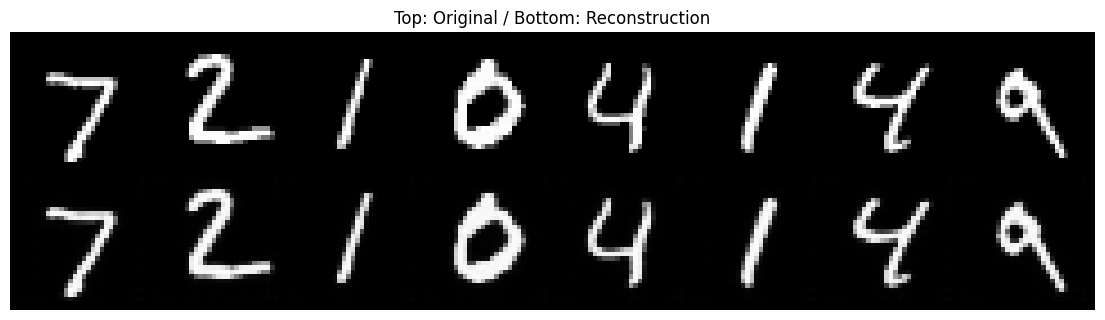

In [7]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    _, x_hat = model(x)

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Original / Bottom: Reconstruction")
    plt.show()

show_reconstructions(model, test_loader, DEVICE)

In [8]:
model = ConvAutoencoder().to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

history = train_autoencoder(
    model, train_loader, criterion, optimizer, DEVICE, epochs=1
)

Epoch 01/1 | Loss: 0.022647


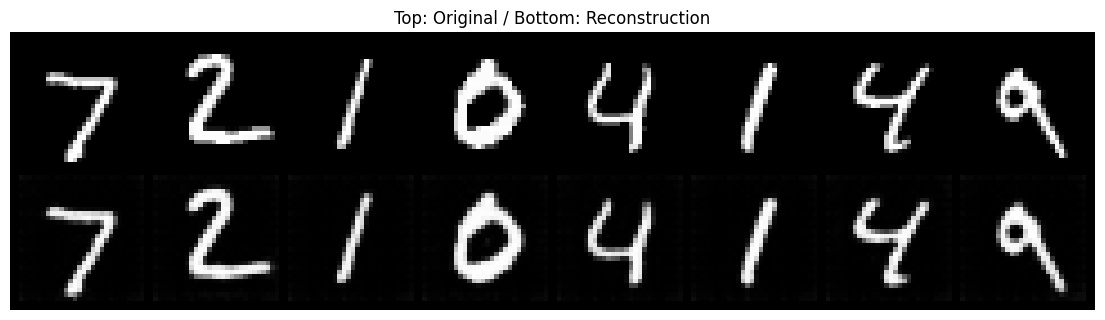

In [9]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    _, x_hat = model(x)

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Original / Bottom: Reconstruction")
    plt.show()

show_reconstructions(model, test_loader, DEVICE)

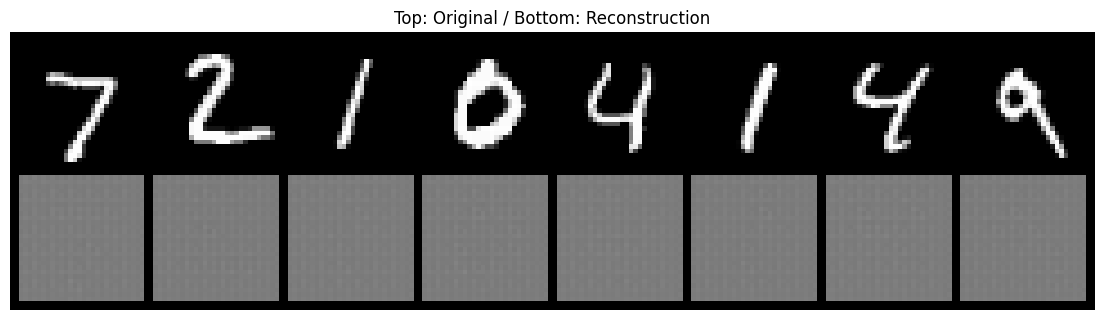

In [10]:
model = ConvAutoencoder().to(DEVICE)

@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    _, x_hat = model(x)

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Original / Bottom: Reconstruction")
    plt.show()

show_reconstructions(model, test_loader, DEVICE)

In [11]:
x, y = next(iter(test_loader))
x = x[:8].to(DEVICE)

with torch.no_grad():
    z = model.encoder(x)

print("입력 shape :", x.shape)
print("latent shape:", z.shape)
print("한 이미지의 원래 값 개수 :", 1 * 28 * 28)
print("한 이미지의 latent 값 개수:", z[0].numel())

입력 shape : torch.Size([8, 1, 28, 28])
latent shape: torch.Size([8, 32, 7, 7])
한 이미지의 원래 값 개수 : 784
한 이미지의 latent 값 개수: 1568


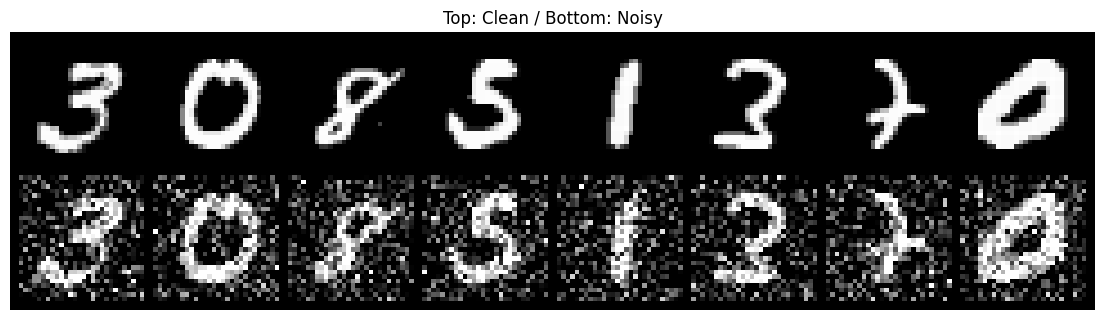

In [12]:
def add_noise(x, noise_factor=0.35):
    noisy = x + noise_factor * torch.randn_like(x)
    return torch.clamp(noisy, 0.0, 1.0)

x, _ = next(iter(train_loader))
noisy_x = add_noise(x[:8])

grid = make_grid(torch.cat([x[:8], noisy_x], dim=0), nrow=8)

plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Top: Clean / Bottom: Noisy")
plt.show()

In [15]:
denoising_model = ConvAutoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.AdamW(denoising_model.parameters(), lr=1e-3)

def train_denoising_autoencoder(model, loader, criterion, optimizer, device, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for clean_x, _ in loader:
            clean_x = clean_x.to(device)
            noisy_x = add_noise(clean_x)

            _, restored_x = model(noisy_x)
            loss = criterion(restored_x, clean_x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * clean_x.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.6f}")

train_denoising_autoencoder(
    denoising_model, train_loader, criterion, optimizer, DEVICE, epochs=5
)

Epoch 01/5 | Loss: 0.039706
Epoch 02/5 | Loss: 0.008205
Epoch 03/5 | Loss: 0.007700
Epoch 04/5 | Loss: 0.007509
Epoch 05/5 | Loss: 0.007368


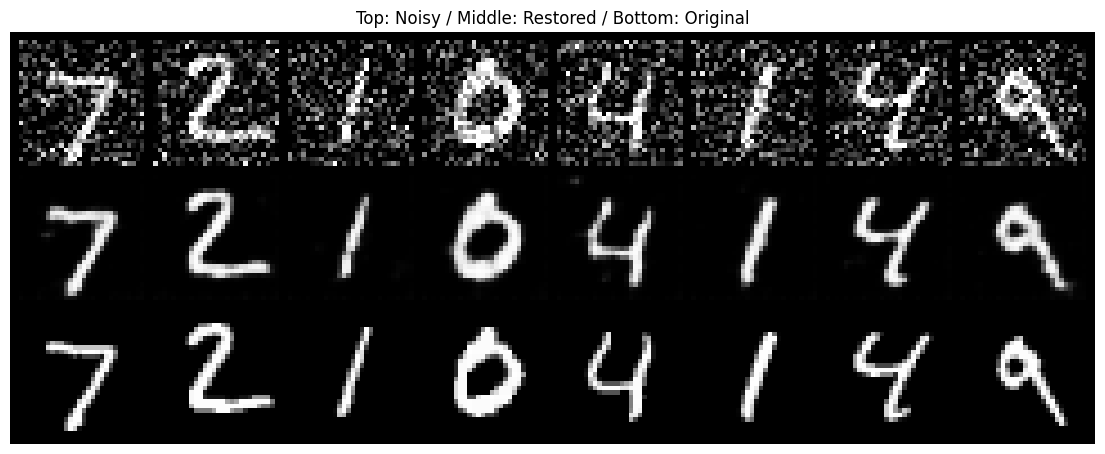

In [17]:
@torch.no_grad()
def show_denoising_result(model, loader, device, n=8):
    model.eval()

    clean_x, _ = next(iter(loader))
    clean_x = clean_x[:n].to(device)
    noisy_x = add_noise(clean_x)

    _, restored_x = model(noisy_x)

    result = torch.cat([
        noisy_x.cpu(),
        restored_x.cpu(),
        clean_x.cpu()
    ], dim=0)

    grid = make_grid(result, nrow=n, padding=2)

    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Noisy / Middle: Restored / Bottom: Original")
    plt.show()

show_denoising_result(denoising_model, test_loader, DEVICE)

In [18]:
mu = torch.tensor([[1.0, 2.0]])
logvar = torch.tensor([[0.0, 0.0]])

std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
z = mu + eps * std

print("mu     :", mu)
print("logvar :", logvar)
print("std    :", std)
print("epsilon:", eps)
print("z      :", z)

mu     : tensor([[1., 2.]])
logvar : tensor([[0., 0.]])
std    : tensor([[1., 1.]])
epsilon: tensor([[0.1690, 1.6344]])
z      : tensor([[1.1690, 3.6344]])


### z를 뽑는 방법

1. 먼저 랜덤 숫자를 뽑음
```
eps = torch.randn_like(std) : 평균 0, 표준편차 1인 정규분포에서 뽑은 랜덤 값
```
2. 랜덤 값을 원하는 위치와 크기로 옮김
```
z = mu(5) + eps(0.3) * std(2)
z = 5.6
```
> 랜덤성을 eps로 만들고 z=mu+eps*std로 계산하면, 랜덤 샘플링을 하면서 mu와 std를 만드는 Encoder를 학습할 수 있음


### VAE Loss
1. Latent 공간을 약속한 기준 분포인 표준정규분포에서 멀리 떨어지지 않도록 정리(KL Divergence)

```
KL Loss
Encoder가 만든 분포가 우리가 기준으로 삼은 N(0, 1)과 너무 멀리 떨어지지 않도록 함

VAE Loss = 복원을 잘 못한 벌점 + latent 공간이 너무 흐트러진 벌점
(Reconstruction Loss + KL Loss)
```

$$
L_{VAE}=L_{reconstruction}+L_{KL}
$$

In [ ]:
import torch.nn.functional as F

LATENT_DIM = 2

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.flatten_dim = 64 * 7 * 7

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        # 1x28x28
        h = self.encoder(x)
        # 64x7x7
        h = h.view(x.size(0), -1)

        # [b, 2]
        mu = self.fc_mu(h)
        # [b, 2]
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 64, 7, 7)

        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar


vae = ConvVAE(latent_dim=LATENT_DIM).to(DEVICE)
print(vae)

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=2, bias=True)
  (fc_decode): Linear(in_features=2, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [20]:
def vae_loss_function(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(
        x_hat, x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    batch_size = x.size(0)

    total_loss = (recon_loss + kl_loss) / batch_size
    recon_loss = recon_loss / batch_size
    kl_loss = kl_loss / batch_size

    return total_loss, recon_loss, kl_loss

In [26]:
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

def train_vae(model, loader, optimizer, device, epochs=10):
    history = {
        "total": [],
        "recon": [],
        "kl": []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        total_sum = 0.0
        recon_sum = 0.0
        kl_sum = 0.0

        for x, _ in loader:
            x = x.to(device)

            optimizer.zero_grad()

            x_hat, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss_function(
                x_hat, x, mu, logvar
            )

            loss.backward()
            optimizer.step()

            total_sum += loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()

        n_batches = len(loader)

        avg_total = total_sum / n_batches
        avg_recon = recon_sum / n_batches
        avg_kl = kl_sum / n_batches

        history["total"].append(avg_total)
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)

        print(
            f"Epoch [{epoch:02d}/{epochs}] "
            f"Total: {avg_total:.4f} | "
            f"Recon: {avg_recon:.4f} | "
            f"KL: {avg_kl:.4f}"
        )

    return history


vae_history = train_vae(
    vae,
    train_loader,
    optimizer,
    DEVICE,
    epochs=20
)

Epoch [01/20] Total: 157.9434 | Recon: 152.4857 | KL: 5.4577
Epoch [02/20] Total: 157.3716 | Recon: 151.8697 | KL: 5.5019
Epoch [03/20] Total: 156.9780 | Recon: 151.4586 | KL: 5.5194
Epoch [04/20] Total: 156.6696 | Recon: 151.1041 | KL: 5.5654
Epoch [05/20] Total: 156.3408 | Recon: 150.7514 | KL: 5.5894
Epoch [06/20] Total: 155.9624 | Recon: 150.3580 | KL: 5.6044
Epoch [07/20] Total: 155.7831 | Recon: 150.1325 | KL: 5.6506
Epoch [08/20] Total: 155.5097 | Recon: 149.8549 | KL: 5.6548
Epoch [09/20] Total: 155.2520 | Recon: 149.5790 | KL: 5.6730
Epoch [10/20] Total: 155.1070 | Recon: 149.4243 | KL: 5.6827
Epoch [11/20] Total: 154.9059 | Recon: 149.2232 | KL: 5.6826
Epoch [12/20] Total: 154.7429 | Recon: 149.0237 | KL: 5.7192
Epoch [13/20] Total: 154.5487 | Recon: 148.8222 | KL: 5.7265
Epoch [14/20] Total: 154.4006 | Recon: 148.6591 | KL: 5.7415
Epoch [15/20] Total: 154.2820 | Recon: 148.5427 | KL: 5.7393
Epoch [16/20] Total: 154.1227 | Recon: 148.3834 | KL: 5.7393
Epoch [17/20] Total: 154

- Total Loss만 보면 VAE가 복원 때문에 좋아지는지, latent 때문에 변하는지 구분하기 어려움
- Recon이 감소되면 Decoder가 입력 이미지를 점점 잘 복원하고 있다는 뜻
- KL이 감소되면 Encoder가 만든 latent distribution을 N(0, I)에 가깝게 정리하는 과정이 일어나고 있다는 뜻
- KL값이 무조건 작을수록 좋다고 단순 해석을 하면 안됨
  - KL이 지나치게 빠르게 0이 되면 Decoder가 latent 정보를 거의 사용하지 않는 현상이 일어남

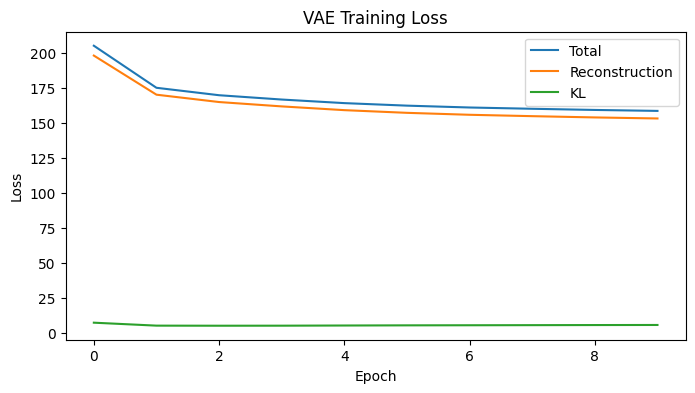

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(vae_history["total"], label="Total")
plt.plot(vae_history["recon"], label="Reconstruction")
plt.plot(vae_history["kl"], label="KL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.show()

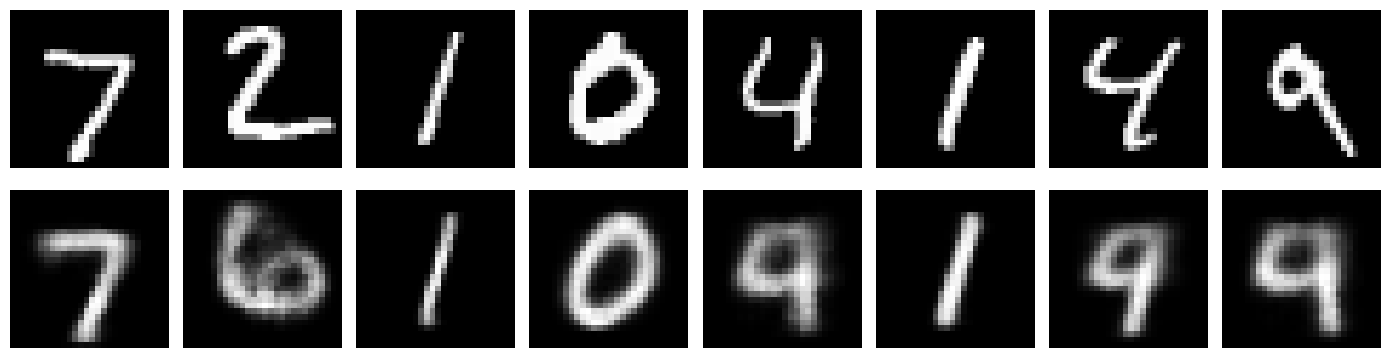

In [27]:
@torch.no_grad()
def show_vae_reconstructions(model, loader, device, n=8):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    x_hat, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(14, 4))

    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_hat[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Recon")

    plt.tight_layout()
    plt.show()


show_vae_reconstructions(vae, test_loader, DEVICE)

- AutoEncoer과 달리 Vae는 중간에서 z를 확률적으로 샘플링 하므로 복원 결과가 부드럽거나 흐릿하게 보일 수 있음.
- 전통적인 VAE에서 자주 보이는 blur은 픽셀 단위와 단순한 decoder 구조 등 여러 요인의 영향을 받음

### 2026년 관점에서 VAE의 중요성
- Diffusion 모델에서 나오거나 Transformer, Flow

- 현재 고품질 이미지 생성의 중심은 단순 VAE 하나만 사용하는 방식이 아니라 Diffusion, Transformer, Flow 계열 등과 결합된 구조로 발전함.
- 대표적으로 latent 기반 생성 모델에서는 고해상도 픽셀 공간을 그대로 다루는 대신, 먼저 이미지를 작은 latent representation으로 압축한 뒤, 그 공간에서 생성 과정을 수행

### 2026년 관점에서 VAE의 중요성

- 현재 고품질 이미지 생성의 중심은 단순 VAE 하나만 사용하는 방식이 아니라 Diffusion, Transformer, Flow 계열 등과 결합된 구조로 발전
- 대표적으로 latent 기반 생성 모델에서는 고해상도 픽셀 공간을 그대로 다루는 대신, 먼저 이미지를 작은 latent representation으로 압축한 뒤 그 공간에서 생성 과정을 수행

```
Image > VAE Encoder > Latent Representation > Diffusion / Transformer 등 생성 모델 >
Generated Latent > VAE Decoder > Generated Image
```

VAE는 확률적인 latent representation을 학습하는 기본 도구이며, 현대 생성 모델의 latent-space 사고방식을 이해하는 중요한 기반